In [1]:

!pip install transformers torch sentencepiece -q



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 90.7 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which

so the contribution i wanted to share was realted to conditioned aptamer generation , based on the pepmlm paper and a paper i shared called bang ,so what i will show you in my code is the architecture , then the training and finetuneing logic and finally there is an evlaution framwork i tried to implement adjacent to sth called deepclip which is a clip/constasive based framwork to determnie where a dna seqeucne will bind with a protein


flag the fag: say their had issue with their masked thing because the ignore index set to 0 , while it should be -100, you ussed nt and for nt the toek 0 is valid, here you didn tfix it but worked around it byt setting the rate to 19 but in reality it is 15 and sincein tn the toekn index 0 is ['<unk>']
 you worked with it

In [2]:
!pip install pyaptamer==0.1.0a1


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 2.6 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 63.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 21.8 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from pyaptamer.datasets import load_aptacom_x_y,
from pyaptamer.datasets.dataclasses import MaskedDataset
import matplotlib.pyplot as plt
from difflib import SequenceMatcher
from torch.optim.lr_scheduler import CosineAnnealingLR
import pandas as pd

### reference paper 
https://arxiv.org/abs/2502.21274 

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, AutoModelForMaskedLM
from torch.utils.data import Dataset, DataLoader

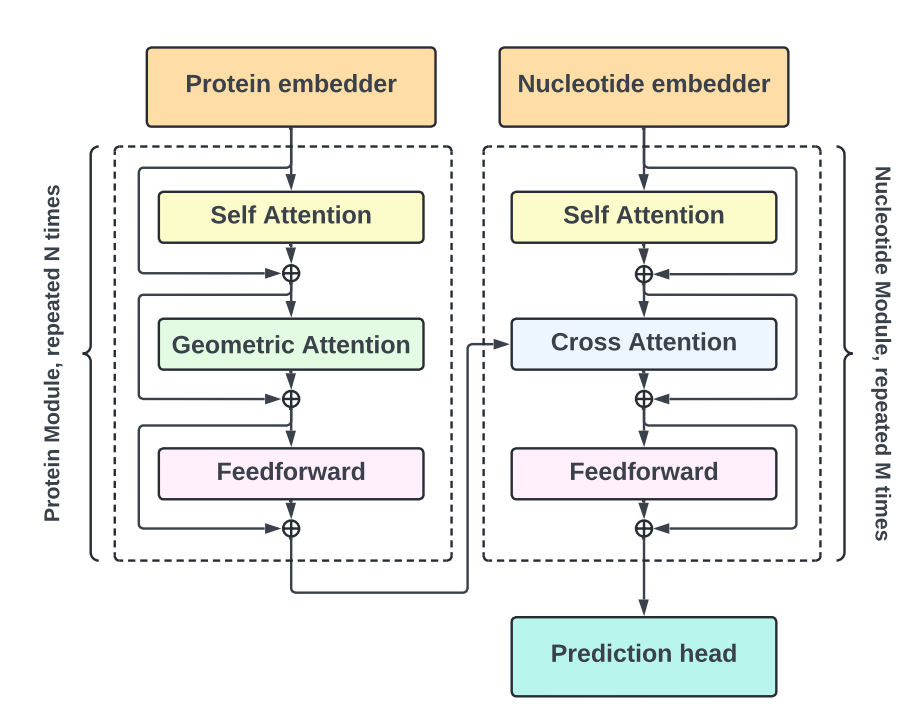


from RNA-BAnG paper  , the architecture I tried to recreate 
 *Geometric attention removed from protein module because this first version works with 1d data sequence (PepMLM), to implement later version for 3d struc protein (pdb)
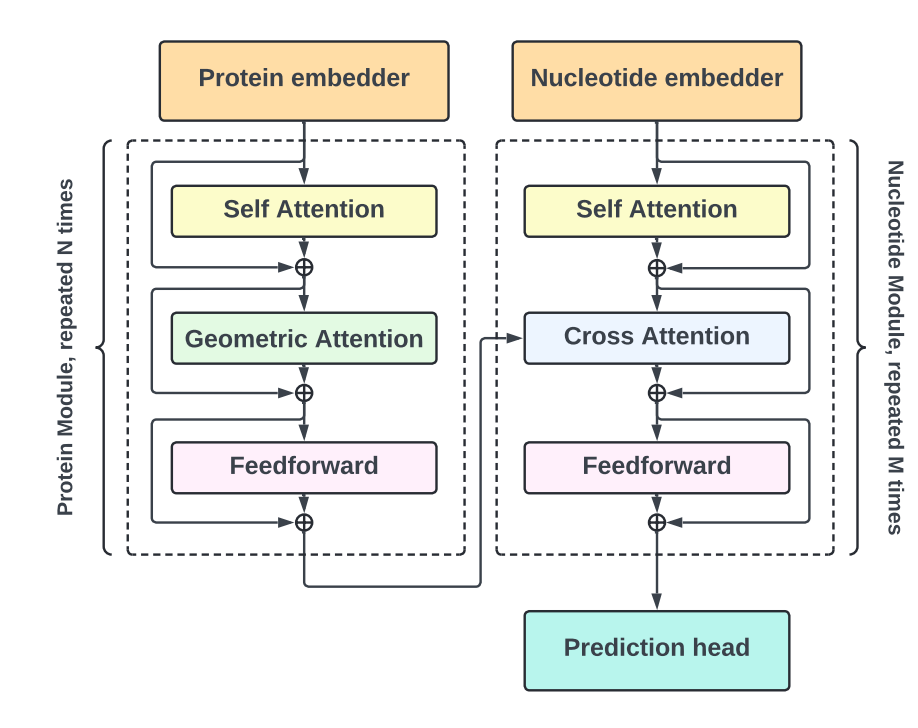

### The frozen encoders to be used to generate embeddings 

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
# protein encoder : ems2 : frozen
prot_tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t33_650M_UR50D")
prot_encoder   = AutoModel.from_pretrained("facebook/esm2_t33_650M_UR50D").to(device)
for p in prot_encoder.parameters():
    p.requires_grad = False
prot_encoder.eval()
 
# nucleotide encoder ,nucTransfor same frozen 
nuc_tokenizer = AutoTokenizer.from_pretrained(
    "InstaDeepAI/nucleotide-transformer-500m-human-ref"
)
nuc_encoder = AutoModelForMaskedLM.from_pretrained(
    "InstaDeepAI/nucleotide-transformer-500m-human-ref"
).to(device)
for p in nuc_encoder.parameters():
    p.requires_grad = False
nuc_encoder.eval()
 
PROT_DIM = 1280   # ESM2 hidden size   #this is the hidden dimension aka the embedding size
NUC_DIM  = 1280   # nucTransfor hidden size   
MASK_TOKEN_ID = nuc_tokenizer.mask_token_id
print(f"MASK token id: {MASK_TOKEN_ID}")  #the id of the[MASK] token

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

EsmForMaskedLM LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                         | Status     |  | 
----------------------------+------------+--+-
esm.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

MASK token id: 2


In [6]:
print(nuc_tokenizer.vocab_size)  #which are???

4107


### the cross attention layer for the nuc module

### the prot module
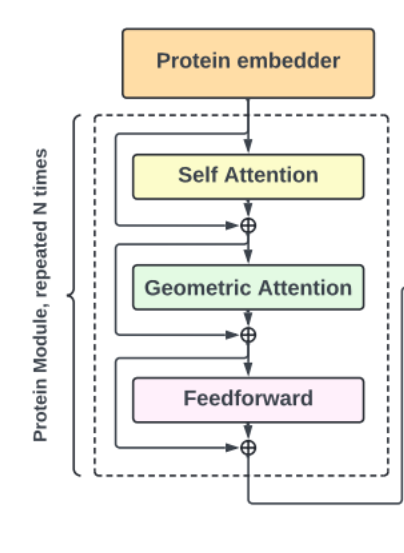

In [8]:
class ProteinModule(nn.Module):
    def __init__(self, prot_dim=1280, d_model=128, n_heads=4, n_layers=3, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
                    nn.Linear(prot_dim, d_model),
                    nn.LayerNorm(d_model),)
        
                #the self attention bloc
        self.blocks = nn.ModuleList([
                    nn.TransformerEncoderLayer(
                        d_model=d_model,
                        nhead=n_heads,
                        dim_feedforward=d_model * 4,
                        dropout=dropout,
                        batch_first=True,
                        activation="gelu",
                    )
                    for _ in range(n_layers)
                ])
    def forward(self, x, padding_mask=None):
        x = self.proj(x)
        for block in self.blocks:
            x = block(x, src_key_padding_mask=padding_mask)
        return x

In [7]:
class CrossAttentionLayer(nn.Module):
    def __init__(self,d_model= 128, n_heads = 4, dropout= 0.1):
        # the communication bridge between the two encoders via attentiopn
      
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
 
    def forward(self, nuc_repr, prot_repr, prot_key_padding_mask=None):
 
        attn_out, _ = self.attn(
            query=nuc_repr,
            key=prot_repr,
            value=prot_repr,
            key_padding_mask=prot_key_padding_mask,  # true = ignore
        )
        return self.norm(nuc_repr + self.dropout(attn_out))

## the nucmodule
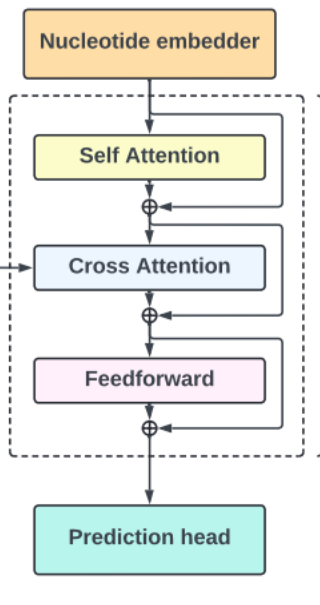

we have proj -- self att -- corss attention -- ffn

In [9]:
class NucleotideModule(nn.Module):
     def __init__(self, nuc_dim=1280, d_model=128, n_heads=4, n_layers=3, dropout=0.1,use_cross_att=True,vocab_size=4000):
         super().__init__()
         self.use_cross_att = use_cross_att
        # self.head = nn.Linear(d_model, vocab_size)

         self.proj = nn.Sequential(
                    nn.Linear(nuc_dim, d_model),
                    nn.LayerNorm(d_model),)
        
                #the self attention bloc
         self.self_attn_blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
                dim_feedforward=d_model*4, dropout=dropout,
                batch_first=True, activation="gelu")
            for _ in range(n_layers)
        ])
         self.cross_attn_blocks = nn.ModuleList([
            CrossAttentionLayer(d_model, n_heads, dropout)
            for _ in range(n_layers)
        ])
         
     def forward(self, nuc, prot=None, nuc_padding_mask=None, prot_padding_mask=None):
        nuc = self.proj(nuc)
        for self_attn, cross_attn in zip(self.self_attn_blocks, self.cross_attn_blocks):
            nuc = self_attn(nuc, src_key_padding_mask=nuc_padding_mask)
            if self.use_cross_att and prot is not None:
                nuc = cross_attn(nuc, prot, prot_key_padding_mask=prot_padding_mask)
        return nuc


## Full architecture



In [10]:
class FullArch(nn.Module):
    def __init__(self, dim=1280, d_model=128, n_heads=4, n_layers=3, dropout=0.1,vocab_size =None):
            super().__init__()
         
            self.protein_module=ProteinModule(dim,d_model,n_heads,n_layers,dropout)
            self.nuc_module=NucleotideModule(dim,d_model,n_heads,n_layers,dropout)
            self.head=nn.Linear(d_model , vocab_size )

    def forward(self, prot_hidden, nuc_hidden, prot_padding_mask=None, nuc_padding_mask=None):
        prot_repr = self.protein_module(prot_hidden, prot_padding_mask)
        nuc_repr  = self.nuc_module(nuc_hidden, prot_repr, nuc_padding_mask, prot_padding_mask)
        logits    = self.head(nuc_repr)
        return logits
    

## Data and dataset class

In [11]:
from pyaptamer.datasets import load_aptacom_x_y,load_li2014

X, y = load_aptacom_x_y(return_X_y=True) #types are df


AptaCom04.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/5556 [00:00<?, ? examples/s]

In [12]:
print(X.columns)
print(y.columns)

print(len(X))
#print(y["new_affinity"].unique())  

Index(['aptamer_sequence', 'target_sequence'], dtype='object')
Index(['new_affinity'], dtype='object')
709


In [23]:
print(y)

     new_affinity
2357     120.0 pM
2358   16000.0 pM
2359    2980.0 pM
2360    3360.0 pM
2361    4700.0 pM
...           ...
3594   37200.0 pM
3607   61000.0 pM
3608   90000.0 pM
3609  247000.0 pM
3610    3500.0 pM

[709 rows x 1 columns]


In [30]:
y.isna().any()

new_affinity    False
dtype: bool

In [24]:
x2,y2=load_li2014()
print(len(x2),len(y2))

2900 2900


In [26]:
print(len(y.isna()))

709


In [14]:
print(y2.columns)
print(x2.columns)
print(y2["label"].unique())

Index(['label'], dtype='object')
Index(['aptamer', 'protein'], dtype='object')
['positive' 'negative']


In [15]:
print(len(y2[y2["label"]=="positive"]))

725


In [32]:
X_aptacom, y_aptacom = load_aptacom_x_y(return_X_y=True)
y_aptacom['affinity_numeric'] = (
    y_aptacom['new_affinity']
    .str.replace(' pM', '', regex=False)
    .astype(float)
)

/tmp/ipykernel_58/2767329082.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_aptacom['affinity_numeric'] = (


In [41]:

# lower pM = better binding

AFFINITY_THRESHOLD = 10000  # pM

aptacom_mask = y_aptacom['affinity_numeric'] <= AFFINITY_THRESHOLD
X_aptacom_pos = X_aptacom[aptacom_mask][['aptamer_sequence', 'target_sequence']].dropna()

print(f"AptaCom positives after affinity filter: {len(X_aptacom_pos)}")


AptaCom positives after affinity filter: 231


In [42]:

x2, y2 = load_li2014()

li_mask = y2['label'] == 'positive'
X_li_pos = x2[li_mask][['aptamer', 'protein']].dropna()
X_li_pos = X_li_pos.rename(columns={
    'aptamer': 'aptamer_sequence',
    'protein': 'target_sequence'   # ← this was missing
})

In [43]:
all_pairs = pd.concat([X_aptacom_pos, X_li_pos], ignore_index=True)
all_pairs = all_pairs.dropna(subset=['aptamer_sequence', 'target_sequence'])
all_pairs = all_pairs.drop_duplicates(subset=['aptamer_sequence', 'target_sequence'])
all_pairs = all_pairs.reset_index(drop=True)

print(f"Total clean positive pairs: {len(all_pairs)}")

Total clean positive pairs: 932


In [44]:
#all_pairs=all_pairs.drop(columns=["protein"])
all_pairs

,aptamer_sequence,target_sequence
0,ACGAAGCUUGAUCCCGUUUGCCGGUCGAUCGCUUCGA,MEPVDPRLEPWKHPGSQPKTACTSCYCKRCCFHCQVCFITKGLGIS...
1,CCTGCCTTTGGCAGCCGGGCGAAGGCAACCCGACACCGACAGC,MKAILVVLLYTFATANADTLCIGYHANNSTDTVDTVLEKNVTVTHS...
2,CCTGCCTTTGGAACCGACCGCCAGGCCGAGGAAAGGCACCGACAGC,MKAILVVLLYTFATANADTLCIGYHANNSTDTVDTVLEKNVTVTHS...
3,GGGAGAGCCAUACCUGACAAAGACGCUAGCGAAUUGGUUCCUCACU...,MAAEGSETNARNSESVRGQIFEVGPRYTNLAYIGEGAYGMVVSAFD...
4,TGTGGGGGTGGACGGGCCGGGTAGA,MERGLPLLCAVLALVLAPAGAFRNDKCGDTIKIESPGYLTSPGYPH...
...,...,...
927,CTTCTGCCCGCCTCCTTCCGACTGTTGGTTCTTGGGAGGAGTGCGG...,MEGMLKGEGPGPLPPLLQQYVELRDQYPDYLLLFQVGDFYECFGED...
928,GUAUUCUCGGUGGUUUAAUCAGAGUAGAGGAGGCUGACUCCUUUGG...,MAGRSGDSDEELLKAVRLIKFLYQSNPPPNPEGTRQARRNRRRRWR...
929,TCCCTACGGCGCTAACGTATAAGTCGCCTGCATCACGGCCAGATTT...,VENLMVQELENFNPPFKLCLHKRDFIPGKWIIDNIIDSIEKSHKTV...
930,CGCACTGAAGTGGGATACCGCCTAAACGG,MKKRKVLIPLMALSTILVSSTGNLEVIQAEVKQENRLLNESESSSQ...


In [46]:
tokenized_nuc2 = nuc_tokenizer(
    all_pairs['aptamer_sequence'].tolist(),
    return_tensors='pt', padding=True,
    truncation=True, max_length=128
)
tokenized_prot2 = prot_tokenizer(
    all_pairs['target_sequence'].tolist(),
    return_tensors='pt', padding=True,
    truncation=True, max_length=512
)

nuc_input_ids2    = tokenized_nuc2['input_ids']
nuc_attn_mask2    = tokenized_nuc2['attention_mask']
prot_input_ids2   = tokenized_prot2['input_ids']
prot_attn_mask2   = tokenized_prot2['attention_mask']


In [47]:
#the fine tuned nt 
checkpoint = torch.load('/kaggle/input/models/majdoubnourelhouda/nt/pytorch/default/1/phase1_aptamer_pretrain.pt', map_location=device)

nuc_encoder.load_state_dict(checkpoint['nuc_encoder'])
for p in nuc_encoder.parameters():
    p.requires_grad = False
nuc_encoder.eval()


EsmForMaskedLM(
  (esm): EsmModel(
    (embeddings): EsmEmbeddings(
      (word_embeddings): Embedding(4105, 1280, padding_idx=1)
      (dropout): Dropout(p=0.0, inplace=False)
      (position_embeddings): Embedding(1002, 1280, padding_idx=1)
    )
    (encoder): EsmEncoder(
      (layer): ModuleList(
        (0-23): 24 x EsmLayer(
          (attention): EsmAttention(
            (self): EsmSelfAttention(
              (query): Linear(in_features=1280, out_features=1280, bias=True)
              (key): Linear(in_features=1280, out_features=1280, bias=True)
              (value): Linear(in_features=1280, out_features=1280, bias=True)
            )
            (output): EsmSelfOutput(
              (dense): Linear(in_features=1280, out_features=1280, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (LayerNorm): LayerNorm((1280,), eps=1e-12, elementwise_affine=True)
          )
          (intermediate): EsmIntermediate(
            (dense): Linea

In [53]:
NUC_VOCAB_SIZE = nuc_tokenizer.vocab_size
MASK_TOKEN_IDX = nuc_tokenizer.mask_token_id

print(NUC_VOCAB_SIZE,MASK_TOKEN_IDX)  #4107

4107 2


In [51]:

full_model = FullArch(
    dim=1280, d_model=128, n_heads=4,
    n_layers=3, dropout=0.1,
    vocab_size=NUC_VOCAB_SIZE
).to(device)

nuc_state = checkpoint['nuc_module']
nuc_state = {k: v for k, v in nuc_state.items() 
             if not k.startswith('head.')}
full_model.nuc_module.load_state_dict(nuc_state)

print("Phase 1 weights loaded into FullArch.")


Phase 1 weights loaded into FullArch.


## Trainning loop

In [54]:

masking_rates       = [0.19, 0.40, 0.65, 1.25]  #the 80% prob
num_epochs_per_stage = 5
batch_size           = 4

optimizer = optim.Adam(full_model.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=len(masking_rates) * num_epochs_per_stage
)

for mask_rate in masking_rates:
    print(f"\n=== Stage: {int(mask_rate*100)}% masking ===")

    masked_dataset = MaskedDataset(
        x=nuc_input_ids2.numpy(),
        y=nuc_input_ids2.numpy(),
        max_len=nuc_input_ids2.shape[1],
        mask_idx=MASK_TOKEN_IDX,
        masked_rate=mask_rate,
        is_rna=False
    )

    train_size = int(0.9 * len(masked_dataset))
    val_size   = len(masked_dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(
        masked_dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(42) 
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    for epoch in range(num_epochs_per_stage):
        full_model.train()
        train_loss = 0

        for batch_idx, (x_masked, y_masked, x_orig, y_orig) in enumerate(train_loader):
            indices = train_ds.indices[
                batch_idx*batch_size : batch_idx*batch_size + x_masked.shape[0]
            ]

            x_masked = x_masked.to(device)
            y_masked = y_masked.to(device)

            with torch.no_grad():
                nuc_hidden = nuc_encoder(
                    x_masked,
                    attention_mask=nuc_attn_mask2[indices].to(device),
                    output_hidden_states=True
                ).hidden_states[-1]               # [B, L, 1280]

                prot_hidden = prot_encoder(
                    prot_input_ids2[indices].to(device),
                    attention_mask=prot_attn_mask2[indices].to(device),
                    output_hidden_states=True
                ).hidden_states[-1]                        # [B, P, 1280]

            nuc_pad_mask  = (nuc_attn_mask2[indices]  == 0).to(device)
            prot_pad_mask = (prot_attn_mask2[indices] == 0).to(device)

            logits = full_model(
                prot_hidden, nuc_hidden,
                prot_pad_mask, nuc_pad_mask
            )                                            

            loss = F.cross_entropy(
                logits.view(-1, NUC_VOCAB_SIZE),
                y_masked.view(-1),
                ignore_index=0   
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(full_model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()
        print(f"  Epoch {epoch+1}/{num_epochs_per_stage} | "
              f"Train Loss: {train_loss/len(train_loader):.4f}")

torch.save({
    'full_model':  full_model.state_dict(),
    'nuc_encoder': nuc_encoder.state_dict(),
}, 'phase2_conditioned.pt')
print("Saved.")


=== Stage: 15% masking ===
  Epoch 1/5 | Train Loss: 1.3028
  Epoch 2/5 | Train Loss: 1.0401
  Epoch 3/5 | Train Loss: 0.8385
  Epoch 4/5 | Train Loss: 0.6908
  Epoch 5/5 | Train Loss: 0.6589

=== Stage: 30% masking ===
  Epoch 1/5 | Train Loss: 0.6223
  Epoch 2/5 | Train Loss: 0.6050
  Epoch 3/5 | Train Loss: 0.6078
  Epoch 4/5 | Train Loss: 0.5892
  Epoch 5/5 | Train Loss: 0.5809

=== Stage: 50% masking ===
  Epoch 1/5 | Train Loss: 0.5763
  Epoch 2/5 | Train Loss: 0.5707
  Epoch 3/5 | Train Loss: 0.5529
  Epoch 4/5 | Train Loss: 0.5354
  Epoch 5/5 | Train Loss: 0.5287

=== Stage: 100% masking ===
  Epoch 1/5 | Train Loss: 0.6560
  Epoch 2/5 | Train Loss: 0.5957
  Epoch 3/5 | Train Loss: 0.5802
  Epoch 4/5 | Train Loss: 0.5735
  Epoch 5/5 | Train Loss: 0.5727
Saved.


In [ ]:
generator_model = full_model
generator_model.eval()

In [57]:


def generate_aptamer(protein_seq_str, model, device, max_len=30, top_k=5):
    prot_tok = prot_tokenizer(
        [protein_seq_str],
        return_tensors='pt', padding=True,
        truncation=True, max_length=512
    )
    prot_ids  = prot_tok['input_ids'].to(device)
    prot_mask = prot_tok['attention_mask'].to(device)

    aptamer_ids = torch.full(
        (1, max_len), MASK_TOKEN_IDX,
        dtype=torch.long, device=device
    )
    nuc_attn = torch.ones(
        (1, max_len), dtype=torch.long, device=device
    )

    with torch.no_grad():
        prot_hidden = prot_encoder(
            prot_ids, attention_mask=prot_mask,
            output_hidden_states=True
        ).hidden_states[-1]

        prot_pad_mask = (prot_mask == 0)

        for pos in range(max_len):
            nuc_hidden = nuc_encoder(
                aptamer_ids, attention_mask=nuc_attn,
                output_hidden_states=True
            ).hidden_states[-1]

            nuc_pad_mask = torch.zeros(
                (1, max_len), dtype=torch.bool, device=device
            )

            logits     = model(prot_hidden, nuc_hidden,
                               prot_pad_mask, nuc_pad_mask)
            logits_pos = logits[0, pos, :]

            # mask out special tokens from sampling
            for special_id in [0, 1, 2, 3, 4]:
                logits_pos[special_id] = -1e9

            top_k_idx  = torch.topk(logits_pos, k=top_k).indices
            best_token = top_k_idx[0].item()
            aptamer_ids[0, pos] = best_token

    generated_seq = nuc_tokenizer.decode(
        aptamer_ids[0],
        skip_special_tokens=True
    ).replace(" ", "")

    return generated_seq
#we run the evaluation by comparing the generated aptamer by our model and how simliari it is to the original one
print("Generating aptamers for sample proteins...\n")
test_indices = [0, 5, 10, 20, 50]

for idx in test_indices:
    if idx < len(all_pairs):
        prot_seq = all_pairs.iloc[idx]['target_sequence']
        orig_apt = all_pairs.iloc[idx]['aptamer_sequence']
        gen_apt  = generate_aptamer(prot_seq, generator_model, device)

        sim = SequenceMatcher(None, orig_apt, gen_apt).ratio()
        print(f"Sample #{idx}")
        print(f"  Protein:   {prot_seq[:50]}...")
        print(f"  Original:  {orig_apt}")
        print(f"  Generated: {gen_apt}")
        print(f"  Similarity: {sim:.3f}\n")

Generating aptamers for sample proteins...

Sample #0
  Protein:   MEPVDPRLEPWKHPGSQPKTACTSCYCKRCCFHCQVCFITKGLGISYGRK...
  Original:  ACGAAGCUUGAUCCCGUUUGCCGGUCGAUCGCUUCGA
  Generated: AAAAACAACAGGGAGAGCGGGGGGGGGGGGGGGGCGGGCC
  Similarity: 0.338

Sample #5
  Protein:   MERGLPLLCAVLALVLAPAGAFRNDKCGDTIKIESPGYLTSPGYPHSYHP...
  Original:  TGTGGGGGAGGACGGGCGGGGATGC
  Generated: AAAAACAACAGGGAGAGCGGGGGGGGGGGGGGGGCGGGCC
  Similarity: 0.492

Sample #10
  Protein:   MERGLPLLCAVLALVLAPAGAFRNDKCGDTIKIESPGYLTSPGYPHSYHP...
  Original:  CGGTAAACTGCGTCCGAAGGGGCTGCAGTGACCCGAATGGGTCCG
  Generated: AAAAACAACAGGGAGAGCGGGGGGGGGGGGGGGGCGGGCC
  Similarity: 0.424

Sample #20
  Protein:   MAHVRGLQLPGCLALAALCSLVHSQHVFLAPQQARSLLQRVRRANTFLEE...
  Original:  AGTCCGTGGTAGGGCAGGTTGGGGTGACT
  Generated: AAAAACAACAGGGAGAGCGGGGGGGGGGGGGGGGCGGGCC
  Similarity: 0.464

Sample #50
  Protein:   MIPARFAGVLLALALILPGTLCAEGTRGRSSTARCSLFGSDFVNTFDGSM...
  Original:  TATAGACCACAGCCTGAGATTAACCACCAACCCAGGACT
  Generated: AAAAACAACA